# Prelude [hidden]

In [ ]:
# helper functions
import glob
import numpy as np
import matplotlib.pyplot as plt
import json 

from ncore.impl.data.types import RowOffsetStructuredSpinningLidarModelParameters
from ncore.impl.sensors.lidar import LidarModel

from typing import Union, Optional
from scipy.interpolate import interp1d

import torch
import numpy as np
import open3d as o3d
import tqdm

def to_torch(
    var: Union[torch.Tensor, np.ndarray],
    device: Union[str, torch.device],
    dtype: Optional[torch.dtype] = None,
) -> torch.Tensor:
    """Converts an input array / tensor to a tensor on the target device (with optional dtype conversion)."""
    if isinstance(var, np.ndarray):
        # Torch doesn't support uint32 and uint64 so we cast them to signed integers beforehand
        # Note that this can cause problems

        if var.dtype == np.uint16:
            assert np.all(var <= np.iinfo(np.int16).max), (
                "[CameraModel]: Trying to cast uint16 to int16 but the value exceeds max range."
            )
            var = var.astype(np.int16)

        if var.dtype == np.uint32:
            assert np.all(var <= np.iinfo(np.int32).max), (
                "[CameraModel]: Trying to cast uint32 to int32 but the value exceeds max range."
            )
            var = var.astype(np.int32)

        if var.dtype == np.uint64:
            assert np.all(var <= np.iinfo(np.int64).max), (
                "[CameraModel]: Trying to cast uint64 to int64 but the value exceeds max range."
            )
            var = var.astype(np.int64)

        var = torch.from_numpy(var)

    return var.to(device=device, dtype=dtype)

def sensor_rays_to_sensor_angles(sensor_rays):
    """Computes the elevation and azimuth angles for normalized 3d sensor rays."""

    # sensor_rays: N x 3 array of sensor rays
    assert sensor_rays.ndim == 2

    sensor_rays = to_torch(sensor_rays, 'cpu')

    sensor_rays /= torch.norm(sensor_rays, dim=-1, keepdim=True)

    elevations_rad = torch.asin(sensor_rays[:, 2])
    azimuths_rad = torch.atan2(sensor_rays[:, 1], sensor_rays[:, 0])

    return azimuths_rad, elevations_rad

def compute_median_elevation_per_ring(all_elevations, all_ring_ids):
    """Fast vectorized computation of median elevation per ring"""
    
    # Sort by ring_id for efficient grouping
    sort_indices = np.argsort(all_ring_ids)
    sorted_ring_ids = all_ring_ids[sort_indices]
    sorted_elevations = all_elevations[sort_indices]
    
    # Find unique ring IDs and their boundaries
    unique_ring_ids, inverse_indices, counts = np.unique(sorted_ring_ids, return_inverse=True, return_counts=True)
    
    # Compute median for each group
    median_elevations = []
    start_idx = 0
    
    for count in counts:
        end_idx = start_idx + count
        group_elevations = sorted_elevations[start_idx:end_idx]
        median_elevations.append(np.median(group_elevations))
        start_idx = end_idx
    
    return unique_ring_ids, np.array(median_elevations)

def collect_azimuth_per_ring(all_azimuths, all_ring_ids, row_azimuth_offsets_rad):
    
    # Sort by ring_id for efficient grouping
    sort_indices = np.argsort(all_ring_ids)
    sorted_ring_ids = all_ring_ids[sort_indices]
    sorted_azimuths = all_azimuths[sort_indices]
    
    # Find unique ring IDs and their boundaries
    unique_ring_ids, inverse_indices, counts = np.unique(sorted_ring_ids, return_inverse=True, return_counts=True)
    
    all_azimuths = []
    start_idx = 0
    for ring_id, count in zip(unique_ring_ids, counts):
        end_idx = start_idx + count
        group_azimuths = sorted_azimuths[start_idx:end_idx]
        group_azimuths -= row_azimuth_offsets_rad[ring_id] # Ring IDs start at 0
        all_azimuths.append(group_azimuths)
        start_idx = end_idx

    return all_azimuths

def interpolate_missing_ring_elevations(unique_ring_ids, median_row_elevations_rad, expected_total_rings=128):
    """
    Interpolate missing ring elevations using linear interpolation.
    
    Parameters:
    -----------
    unique_ring_ids : array-like
        Ring IDs that were found in the data
    median_row_elevations_rad : array-like  
        Measured median elevations for the found rings (in radians)
    expected_total_rings : int
        Total number of rings expected (default 128 for Hesai AT128)
        
    Returns:
    --------
    complete_ring_ids : np.array
        Complete sequence of ring IDs from ring_start to ring_start+expected_total_rings-1
    complete_elevations_rad : np.array
        Elevations for all rings (measured + interpolated)
    interpolated_mask : np.array
        Boolean mask indicating which values were interpolated (True = interpolated)
    """
    
    # Convert to numpy arrays and sort by ring ID
    unique_ring_ids = np.array(unique_ring_ids)
    median_row_elevations_rad = np.array(median_row_elevations_rad)
    
    # Sort by ring ID to ensure proper ordering
    sort_indices = np.argsort(unique_ring_ids)
    sorted_ring_ids = unique_ring_ids[sort_indices]
    sorted_elevations = median_row_elevations_rad[sort_indices]
    
    # Create complete ring ID sequence
    complete_ring_ids = np.arange(expected_total_rings)
    
    # Initialize output arrays
    complete_elevations_rad = np.full(expected_total_rings, np.nan)
    interpolated_mask = np.ones(expected_total_rings, dtype=bool)  # True = interpolated

    complete_elevations_rad[sorted_ring_ids] = sorted_elevations
    interpolated_mask[sorted_ring_ids] = False  # False = measured (not interpolated)
    

    measured_count = np.sum(~interpolated_mask)
    missing_count = np.sum(interpolated_mask)
    
    if measured_count < 2:
        print("Error: Need at least 2 measured rings for interpolation")
        return complete_ring_ids, complete_elevations_rad, interpolated_mask
    
        
    if missing_count == 0:
        return complete_ring_ids, complete_elevations_rad, interpolated_mask

    # Create interpolation function
    measured_rings = sorted_ring_ids
    measured_elevs = sorted_elevations
    
    interp_func = interp1d(measured_rings, measured_elevs, 
                          kind='linear', fill_value='extrapolate')
    
    # Fill missing values
    missing_indices = np.where(interpolated_mask)[0]

    missing_ring_positions = complete_ring_ids[missing_indices]
    interpolated_elevations = interp_func(missing_ring_positions)
    complete_elevations_rad[missing_indices] = interpolated_elevations
        
    return complete_ring_ids, complete_elevations_rad, interpolated_mask

# calculate element id
def compute_lidar_model_elements(
    lidar_model_parameters,
    lidar_model,
    lidar_frame_range,
    tqdm_disabled,
    positions_list,
    ring_ids_list
) -> dict[int, np.ndarray]:
    """
    Compute per frame model element indices based on GT point cloud and LidarModel.

    Args:
        lidar_model_parameters (ConcreteLidarModelParametersUnion): The lidar model parameters, such as the row elevations
        lidar_frame_range (range): The frame range for which to compute the model parameters
        tqdm_disabled (bool): When True, will not show progress bars

    Returns:
        lidar_model_elements (dict[int, np.ndarray]): Returns the per-frame lidar model elements
    """

    lidar_model_elements: dict[int, np.ndarray] = {}
    lidar_sensor_angles: dict[int, np.ndarray] = {}

    # Iterate through each frame in lidar_frame_ranges
    for lidar_frame_index in tqdm.tqdm(lidar_frame_range, desc="Nominal Lidar Elements", disable=tqdm_disabled):
        # load ring id for the current frame
        ring_ids = ring_ids_list[lidar_frame_index].squeeze()
        # Get the ground truth point cloud for the current frame
        pc_lidar_gt = positions_list[lidar_frame_index]

        pc_lidar_gt = pc_lidar_gt / np.linalg.norm(pc_lidar_gt, axis=-1, keepdims=True)
        angles = lidar_model.sensor_rays_to_sensor_angles(torch.tensor(pc_lidar_gt, device="cuda")).sensor_angles

        azimuths_offsets_rad = lidar_model_parameters.row_azimuth_offsets_rad[ring_ids]
        azimuths_rad = angles[:, 1] - torch.from_numpy(azimuths_offsets_rad).cuda()
        horizontal_idxs = (
            (
                torch.abs(
                    torch.tensor(lidar_model_parameters.column_azimuths_rad[:, None], device="cuda") - azimuths_rad
                ).argmin(dim=0)
            )
            .to(torch.long)
            .cpu()
            .numpy()
        )
        horizontal_idxs = np.clip(horizontal_idxs, 0, lidar_model_parameters.n_columns - 1, out=None)
        lidar_model_elements[lidar_frame_index] = np.stack([ring_ids, horizontal_idxs], axis=-1).astype(np.uint16)
        lidar_sensor_angles[lidar_frame_index] = angles

    return lidar_model_elements, lidar_sensor_angles


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# LIDAR preprocess

This tutorial provides guidance for estimating RowOffsetStructuredSpinningLidarModelParameters, per-point model-IDs, and visualize estimation errors.

## Section 1: LIDAR model parameter estimation for AT128

### Step1: get nominal LiDAR model parameters from the manual

In [ ]:
# need to configure row_azimuth_offsets_rad according to the manual
row_azimuth_offsets_rad = np.empty_like(128)

### Step2: load raw point clouds with positions, and ring IDs
Please replace with your own data directory path for preprocess.

Positions are before motion compensation.

Ring IDs start from 0.

In [ ]:
raw_path = "/dataset/lidar_before_motion_compensation/"
raw_files_path_sorted = sorted(glob.glob(raw_path + "*.ply"))

positions_list = []
ring_ids_list = []

for current_frame_idx in range(len(raw_files_path_sorted)):
    pcd = o3d.t.io.read_point_cloud(raw_files_path_sorted[current_frame_idx])
    positions_list.append(pcd.point.positions.numpy())
    ring_ids_list.append(pcd.point.rings.numpy())

### Step3: calculate elevation and azimuth angles, and collect ring IDs and frame indices

In [4]:
all_elevations = []
all_azimuths = []
all_ring_ids = []
all_frame_indices = []
for current_frame_idx in range(len(raw_files_path_sorted)):
    positions = positions_list[current_frame_idx]
    rings = ring_ids_list[current_frame_idx]
    azimuths_rad, elevations_rad = sensor_rays_to_sensor_angles(positions)
    all_elevations.append(elevations_rad)
    all_azimuths.append(azimuths_rad)
    all_ring_ids.append(rings)
    all_frame_indices.append(current_frame_idx * np.ones_like(rings))

all_elevations = np.concatenate(all_elevations)
all_azimuths = np.concatenate(all_azimuths)
all_ring_ids = np.concatenate(all_ring_ids)
all_frame_indices = np.concatenate(all_frame_indices)

### Step4: estimate LIDAR model parameters
HERE WE MAKE TWO ASSUMPTIONS:
1) The sequence contains at least one point from each of the 128 rings in at least one of the frames (this is not the case for the Xiaomi sequence - see the interpolation method there for a general solution)
2) We assume that the across the frames we get at least one measurement from the first and one from the last column.

In [ ]:
# Get median value of elevation radius in each ring group
unique_ring_ids, median_row_elevations_rad = compute_median_elevation_per_ring(all_elevations.squeeze(), all_ring_ids.squeeze())
all_azimuths_per_ring = collect_azimuth_per_ring(all_azimuths.squeeze(), all_ring_ids.squeeze(), row_azimuth_offsets_rad)

# Interpolate missing ring elevations using linear interpolation.
if median_row_elevations_rad.shape[0] < row_azimuth_offsets_deg.shape[0]:
    unique_ring_ids, median_row_elevations_rad, interpolated_mask = interpolate_missing_ring_elevations(unique_ring_ids, median_row_elevations_rad, expected_total_rings=row_azimuth_offsets_deg.shape[0])

# Analyze the azimuths per ring
min_max_azimuths = []

for ring_id, azimuths in enumerate(all_azimuths_per_ring):
    min_max_azimuths.append((np.min(azimuths), np.max(azimuths)))

# Convert to numpy arrays for easier handling
min_azimuth = np.min(np.degrees(np.array([minmax[0] for minmax in min_max_azimuths])))
max_azimuth = np.max(np.degrees(np.array([minmax[1] for minmax in min_max_azimuths])))

azimuth_spans_deg = max_azimuth - min_azimuth
# The attributes are from Hesai_AT128 manual.
column_azimuths_rad_1 = np.deg2rad(np.arange(max_azimuth, min_azimuth, -0.1))

lidar_model_dict = {
    "spinning_frequency_hz": 10.0,
    "spinning_direction": "cw",
    "n_rows": 128,
    "n_columns": column_azimuths_rad_1.shape[0],
    "row_elevations_rad": median_row_elevations_rad.tolist(),
    "column_azimuths_rad": column_azimuths_rad_1.tolist(),
    "row_azimuth_offsets_rad": row_azimuth_offsets_rad.tolist()
}

# Write back to file
with open("estimated_model_hesai_at128.json", 'w') as f:
    json.dump(lidar_model_dict, f, indent=4)

## Section 2: Per-point model ID estimation

### Step1: load estimated lidar model parameters

In [6]:
lidar_model_dict = json.load(open("estimated_model_hesai_at128.json"))
lidar_model_parameters = RowOffsetStructuredSpinningLidarModelParameters.from_dict(lidar_model_dict)
lidar_model = LidarModel.maybe_from_parameters(lidar_model_parameters)

### Step2: compute per-point model IDs

In [7]:
lidar_model_elements, lidar_sensor_angles = compute_lidar_model_elements(lidar_model_parameters=lidar_model_parameters,
                                                    lidar_model=lidar_model,
                                                    lidar_frame_range=range(len(raw_files_path_sorted)),
                                                    tqdm_disabled=False,
                                                    positions_list=positions_list,
                                                    ring_ids_list=ring_ids_list
)

Nominal Lidar Elements: 100%|██████████| 307/307 [00:01<00:00, 257.03it/s]


## Section 3: estimation error visualization

### Step1: calculate differences between GT angles and angles calculated from model IDs

In [8]:
gt_sensor_elevations_diffs = []
gt_sensor_azimuths_diffs = []
for frame_index in range(len(raw_files_path_sorted)):
    gt_sensor_angles = lidar_sensor_angles[frame_index].cpu().numpy()
    sensor_angles = lidar_model.elements_to_sensor_angles(lidar_model_elements[frame_index]).cpu().numpy()

    gt_sensor_elevations = gt_sensor_angles[:, 0]
    gt_sensor_azimuths = gt_sensor_angles[:, 1]

    sensor_elevations = sensor_angles[:, 0]
    sensor_azimuths = sensor_angles[:, 1]

    gt_sensor_elevations_diff = np.rad2deg(np.abs(gt_sensor_elevations - sensor_elevations))
    gt_sensor_azimuths_diff = np.rad2deg(np.abs(gt_sensor_azimuths - sensor_azimuths))

    gt_sensor_elevations_diffs.append(gt_sensor_elevations_diff.flatten())
    gt_sensor_azimuths_diffs.append(gt_sensor_azimuths_diff.flatten())

gt_sensor_elevations_diffs = np.concatenate(gt_sensor_elevations_diffs)
gt_sensor_azimuths_diffs = np.concatenate(gt_sensor_azimuths_diffs)

### Step2: visualize these differences through histograms

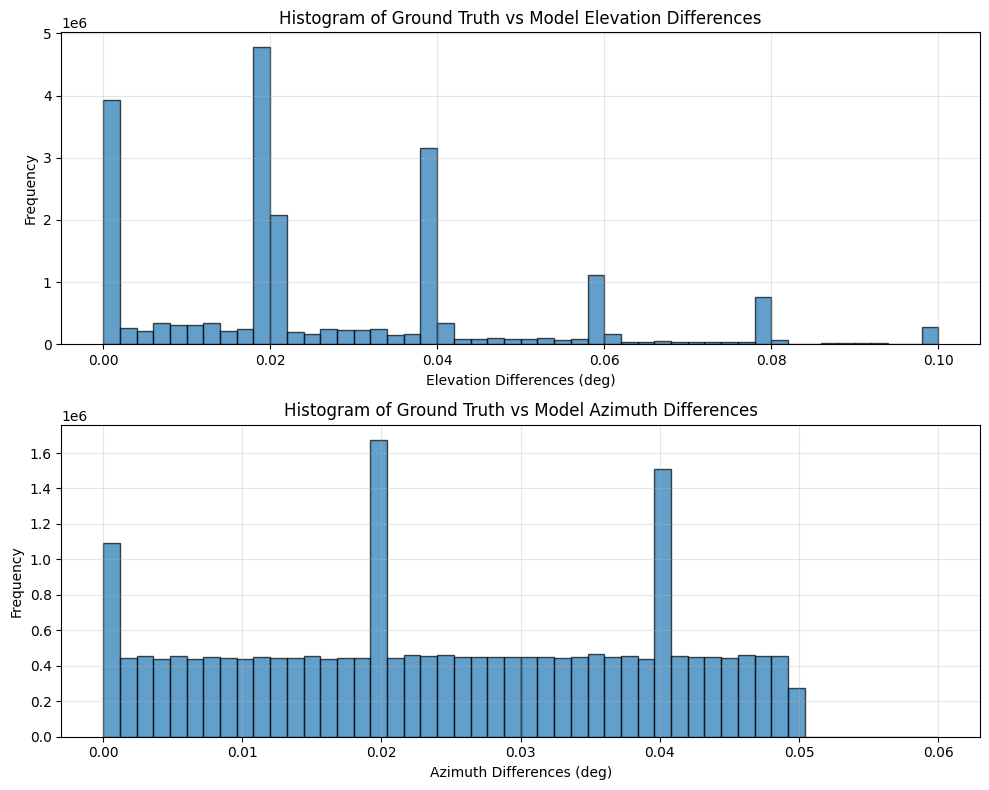

Elevation differences - Mean: 0.027050, Std: 0.022648, Max: 0.100002
Azimuth differences - Mean: 0.024772, Std: 0.014532, Max: 0.060010


In [9]:
# Create histograms for elevation and azimuth differences
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Histogram for elevation differences
ax1.hist(gt_sensor_elevations_diffs, bins=50, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Elevation Differences (deg)')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram of Ground Truth vs Model Elevation Differences')
ax1.grid(True, alpha=0.3)

# Histogram for azimuth differences
ax2.hist(gt_sensor_azimuths_diffs.flatten(), bins=50, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Azimuth Differences (deg)')
ax2.set_ylabel('Frequency')
ax2.set_title('Histogram of Ground Truth vs Model Azimuth Differences')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Elevation differences - Mean: {np.mean(gt_sensor_elevations_diffs):.6f}, "
        f"Std: {np.std(gt_sensor_elevations_diffs):.6f}, "
        f"Max: {np.max(gt_sensor_elevations_diffs):.6f}")
print(f"Azimuth differences - Mean: {np.mean(gt_sensor_azimuths_diffs):.6f}, "
        f"Std: {np.std(gt_sensor_azimuths_diffs):.6f}, "
        f"Max: {np.max(gt_sensor_azimuths_diffs):.6f}")